# Classification of Stress from Physiological data

In [1]:
%matplotlib widget
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.figure as figure
import pandas as pd
from datetime import datetime
import joblib

from IPython.display import display

from imblearn.over_sampling import ADASYN
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC
from sklearn.metrics import ConfusionMatrixDisplay, classification_report, confusion_matrix, balanced_accuracy_score, f1_score
from sklearn.pipeline import Pipeline

from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer, SimpleImputer
from sklearn.feature_selection import RFECV

from make_classification import avg_res, make_nclassif_random_splits, make_nclassif_kfold

STD_BY_SUBJ = True
std_suffix = ".stdsubj" if STD_BY_SUBJ else ".stdtask"

BASE_PATH = "../../experiment-data"
LABELS_SEPARATOR = ","
LABELS_FILENAME = f"{BASE_PATH}/labels.csv"
FEATURES_SEPARATOR = ";"
FEATURES_DIRECTORY = f"{BASE_PATH}/extracted-features"
FEATURES_FILENAME = f"{FEATURES_DIRECTORY}/all_features{std_suffix}.csv"
RESULTS_SEPARATOR = ","
RESULTS_DIRECTORY = f"{BASE_PATH}/results/InterTasks"
BIN_LABELS = ["NoStress", "Stress"]
TER_LABELS = ["Relaxed", "Stress", "RealStress"]
QAD_LABELS = ["Relaxed", "Stress", "RealStress", "Amused"]
DEBUG = True
FLOAT_TYPE = np.float64

STRESS_TASKS = ["Baseline", "AmusementClip", "StressClip"]
FRUSTRATION_TASKS = ["EmoReset", "FormL", "FormM"]

In [2]:
def make_results_filename(classification: str, feature_selection: str | None, state_int: int) -> str:
    now = datetime.now()
    timestamp = now.strftime("%Y%m%d-%H%M%S")
    feature_selection = feature_selection if feature_selection is not None else "None"
    return f"{RESULTS_DIRECTORY}/{timestamp}_{classification}_{feature_selection}f.{state_int}"

def show_label_stats(labels: list[str], y: pd.Series):
    df = pd.DataFrame(
        {
            "labels": labels,
            "counts": y.value_counts().to_list(),
            "percentage": (y.value_counts(normalize=True) * 100).to_list(),
        },
    )
    display(df.set_index("labels"))

def output(results: pd.DataFrame, conf_matrices: dict[str, np.ndarray], meta: dict):
    classification = f"{meta['classification']}_{meta['training_tasks']}"
    feature_selector = meta['feature_selector']
    state_int = meta['state_int']
    labels = meta['classes']
    averages = avg_res(results)
    if meta['save_results']:
        res_file = make_results_filename(classification, feature_selector, state_int) + ".csv"
        avg_file = make_results_filename(classification, feature_selector, state_int) + ".avg.csv"
        print(f"Saving results to {res_file}, {avg_file}")
        results.to_csv(res_file, sep=RESULTS_SEPARATOR, index=True)
        averages.to_csv(avg_file, sep=RESULTS_SEPARATOR, index=True)

    # Show results
    if meta['show_averages']:
        display(averages)
    if meta['show_confusion_matrices']:
        cm_file = make_results_filename(classification, feature_selector, state_int) + ".CM.png"
        ncms = len(conf_matrices)
        pairs = [(name, cm) for name, cm in conf_matrices.items()]
        nrows = (ncms // 2) + (ncms % 2)
        fig, axes = plt.subplots(nrows, 2, figsize=(8, nrows*4))
        for (name, cm), ax in zip(pairs, axes.ravel()):
            disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
            disp.plot(cmap=plt.cm.Blues, ax=ax, colorbar=False)
            ax.set_title(name)
        fig.suptitle("Confusion Matrices")
        plt.tight_layout()
        if meta["save_results"]:
            print(f"Saving confusion matrix to {cm_file}")
            plt.savefig(cm_file, dpi=300, format="png")
        plt.show()


def save_models(classifiers: dict[str, Pipeline], meta: dict):
    classification = f"{meta['classification']}_{meta['training_tasks']}"
    for name, cls in classifiers.items():
        now = datetime.now()
        timestamp = now.strftime("%Y%m%d-%H%M%S")
        filename = (
            f"{RESULTS_DIRECTORY}/{timestamp}_{classification}_{name}_{meta['feature_selector']}f.joblib"
        )
        joblib.dump(cls, filename)
        print(f"Model {name} saved to {filename}")

def show_results(log_prefix: str, results: pd.DataFrame, meta: dict, save=False):
    feature_selector = meta["feature_selector"]
    state_int = meta["state_int"]
    display(results)
    if save:
        res_file = make_results_filename(log_prefix, feature_selector, state_int) + ".csv"
        print(f"Saving results to {res_file}")
        results.to_csv(res_file, sep=RESULTS_SEPARATOR, index=True)


def show_confusion_matrices(log_prefix: str, conf_matrices: dict[str, np.ndarray], meta: dict, save=False):
    feature_selector = meta["feature_selector"]
    state_int = meta["state_int"]
    labels = meta["classes"]
    cm_file = make_results_filename(log_prefix, feature_selector, state_int) + ".CM.png"
    ncms = len(conf_matrices)
    pairs = [(name, cm) for name, cm in conf_matrices.items()]
    nrows = (ncms // 2) + (ncms % 2)
    fig, axes = plt.subplots(nrows, 2, figsize=(8, nrows * 4))
    for (name, cm), ax in zip(pairs, axes.ravel()):
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
        disp.plot(cmap=plt.cm.Blues, ax=ax, colorbar=False)
        ax.set_title(name)
    fig.suptitle("Confusion Matrices")
    plt.tight_layout()
    if save:
        print(f"Saving confusion matrix to {cm_file}")
        plt.savefig(cm_file, dpi=300, format="png")
    plt.show()

#### Import labels and prepare dataset

Manually engineered features

In [3]:
X = pd.read_csv(FEATURES_FILENAME, sep=FEATURES_SEPARATOR, header=0, index_col=0).dropna()
for col in X.columns:
    X[col] = X[col].astype(FLOAT_TYPE)
n_rows, n_cols = X.shape
print("======================================================")
print(f"Experiment dataset contains {n_rows} samples with {n_cols} features")
# display(X)

labels = pd.read_csv(LABELS_FILENAME, sep=LABELS_SEPARATOR, header=0, index_col=0).dropna()
n_rows, n_cols = labels.shape
print("======================================================")
print(f"Experiment labels contains {n_rows} labels with {n_cols} types of classifications")
# display(labels)

# Selecting rows that actually have entries both labels and samples
idx = list(X.merge(labels, left_index=True, right_index=True).index)
labels = labels.loc[idx]
X = X.loc[idx]
n_rows, n_cols = X.shape
print("======================================================")
print(f"Experiment classification dataset contains {n_rows} samples with {n_cols} features")

stress_tasks_mask = [task.split("-")[1] in STRESS_TASKS for task in X.index]
stress_X = X[stress_tasks_mask]
stress_bin_y = labels['binary-stress'][stress_tasks_mask]
stress_ter_y = labels['affect3-class'][stress_tasks_mask]
stress_qad_y = labels['affect4-class'][stress_tasks_mask]

frust_tasks_mask = [task.split("-")[1] in FRUSTRATION_TASKS for task in X.index]
frust_X = X[frust_tasks_mask]
frust_bin_y = labels["binary-stress"][frust_tasks_mask]
frust_ter_y = labels["affect3-class"][frust_tasks_mask]
frust_qad_y = labels["affect4-class"][frust_tasks_mask]

def subject_to_group(subjID):
    return int(subjID) - 1

stress_subject_list: list[int] = []
frust_subject_list: list[int] = []
for sample_name in labels["binary-stress"].index:
    subject_id, task = sample_name.split("-")
    if task in STRESS_TASKS:
        stress_subject_list.append(subject_to_group(subject_id))
    else:
        frust_subject_list.append(subject_to_group(subject_id))

n_rows, n_cols = stress_X.shape
print("\n======================================================")
print(f"Stress (Video) tasks dataset contains {n_rows} samples with {n_cols} features")
print(f"Stress tasks subjects list is {len(stress_subject_list)} members long, having {len(set(stress_subject_list))} distinct subjects.")
n_rows, n_cols = frust_X.shape
print("======================================================")
print(f"Frustration (Calculator) tasks dataset contains {n_rows} samples with {n_cols} features")
print(
    f"Frustration tasks subjects list is {len(frust_subject_list)} members long, having {len(set(frust_subject_list))} distinct subjects."
)

Experiment dataset contains 147 samples with 70 features
Experiment labels contains 126 labels with 3 types of classifications
Experiment classification dataset contains 126 samples with 70 features

Stress (Video) tasks dataset contains 63 samples with 70 features
Stress tasks subjects list is 63 members long, having 21 distinct subjects.
Frustration (Calculator) tasks dataset contains 63 samples with 70 features
Frustration tasks subjects list is 63 members long, having 21 distinct subjects.


# Training, Statistical features

Several models are tested: Random Forests, K nearets neighbors, SVM, and Multi Layer Perceptron. All models are fitted 10 times on random splits and 5-fold, and the average scores of the repetitions are reported.

### Parameter and models configuration

In [4]:
training_tasks = "video"  # Literal["video" | "calc"]
params = {
    "training_tasks": training_tasks,
    "testing_tasks": "calc" if training_tasks == "video" else "video",
    "state_int": 21,
    "feature_selector": "RFE",  # None, 'PCA', 'L1', or 'RFE' (ordered by speed)
    "test_size": 0.2,  # Paper value: 0.2
    "n_splits": 10,  # Paper value: 10
    "data_augmentation": True,
    "show_averages": True,
    "show_confusion_matrices": True,
    "save_confusion_matrices": True,
    "save_models": False,
    "save_results": True,
    "verbose": False,
}

validations = {
    'holdout': True,
    'kfold': True
}

list_classif = [
    RandomForestClassifier(bootstrap=True, max_depth=40, max_features="log2", min_samples_leaf=1, min_samples_split=2, n_estimators=450, random_state=params["state_int"]),
    KNeighborsClassifier(n_neighbors=2, p=1, weights="distance"),
    SVC(C=1000, gamma="auto", kernel="rbf", random_state=params["state_int"], probability=True),
    MLPClassifier(activation="tanh", alpha=0.008, hidden_layer_sizes=(100,), learning_rate_init=0.005, max_iter=10000, random_state=params["state_int"]),
]

if params["training_tasks"] == "video":
    trainset_name = "Stress Tasks"
    trainset_x = stress_X.copy()
    trainset_bin_y = stress_bin_y.copy()
    trainset_ter_y = stress_ter_y.copy()
    trainset_qad_y = stress_qad_y.copy()
    trainsubject_list = stress_subject_list.copy()
    testset_name = "Frustration Tasks"
    testset_x = frust_X.copy()
    testset_bin_y = frust_bin_y.copy()
    testset_ter_y = frust_ter_y.copy()
    testset_qad_y = frust_qad_y.copy()
    testsubject_list = frust_subject_list.copy()
else:
    trainset_name = "Frustration Tasks"
    trainset_x = frust_X.copy()
    trainset_bin_y = frust_bin_y.copy()
    trainset_ter_y = frust_ter_y.copy()
    trainset_qad_y = frust_qad_y.copy()
    trainsubject_list = frust_subject_list.copy()
    testset_name = "Stress Tasks"
    testset_x = stress_X.copy()
    testset_bin_y = stress_bin_y.copy()
    testset_ter_y = stress_ter_y.copy()
    testset_qad_y = stress_qad_y.copy()
    testsubject_list = stress_subject_list.copy()

### Binary classification

In [ ]:
params['classification'] = 'binary'
params['classes'] = BIN_LABELS
show_label_stats(params['classes'], trainset_bin_y)

if params["data_augmentation"]:
    ada = ADASYN(random_state=params["state_int"], sampling_strategy={0:60, 1:60}) # sampling_strategy={0:41, 1:41}) for video
    x_in, y_in = ada.fit_resample(trainset_x, trainset_bin_y)
    print("Resampled dataset")
    show_label_stats(params["classes"], y_in)
else:
    x_in = trainset_x.copy()
    y_in = trainset_bin_y.copy()

    # Visualise class distribution
    plt.figure(figsize=(12, 6))

    bin_stats = pd.DataFrame(
        {
            "Value": y_in.values,
            "Subject": [idx.split("-")[0] for idx in y_in.index],
            "Task": [idx.split("-")[1] for idx in y_in.index],
        },
        index=y_in.index,
    )
    for cls_id, cls_name in enumerate(params["classes"]):
        bin_stats[cls_name] = [value == cls_id for value in y_in]

    tasks = sorted(bin_stats['Task'].unique())
    x_positions = np.arange(len(tasks))
    width = 0.35

    # Plot bars and scatter points for each class
    for i, class_name in enumerate(params["classes"]):
        counts = bin_stats.groupby('Task')[class_name].sum()
        bars = plt.bar(x_positions + (i-0.5)*width, [counts[task] for task in tasks], width,
                        label=class_name, alpha=0.7)

    plt.xlabel('Task')
    plt.ylabel('Count')
    plt.title('Number of instances per class by Task')
    plt.xticks(x_positions, tasks, rotation=45)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    print("\nInstances count per task:")
    display(bin_stats.groupby('Task')[params["classes"]].sum())

,counts,percentage
labels,,
NoStress,45,71.428571
Stress,18,28.571429


Resampled dataset


,counts,percentage
labels,,
NoStress,63,50.806452
Stress,61,49.193548


Split  1/10
Split  2/10
Split  3/10
Split  4/10
Split  5/10
Split  6/10
Split  7/10
Split  8/10
Split  9/10
Split 10/10
Saving results to ../../experiment-data/results/InterTasks/20251021-163135_binary_video_RFEf.21.csv, ../../experiment-data/results/InterTasks/20251021-163135_binary_video_RFEf.21.avg.csv


,f1-score,accuracy,time
classifier,,,
KNeighborsClassifier,0.872191,0.879333,4.954412
MLPClassifier_HLs(100),0.944488,0.948225,4.735266
RandomForestClassifier,0.911497,0.911605,4.932031
SVC,0.960232,0.961882,4.874677


Saving confusion matrix to ../../experiment-data/results/InterTasks/20251021-163135_binary_video_RFEf.21.CM.png


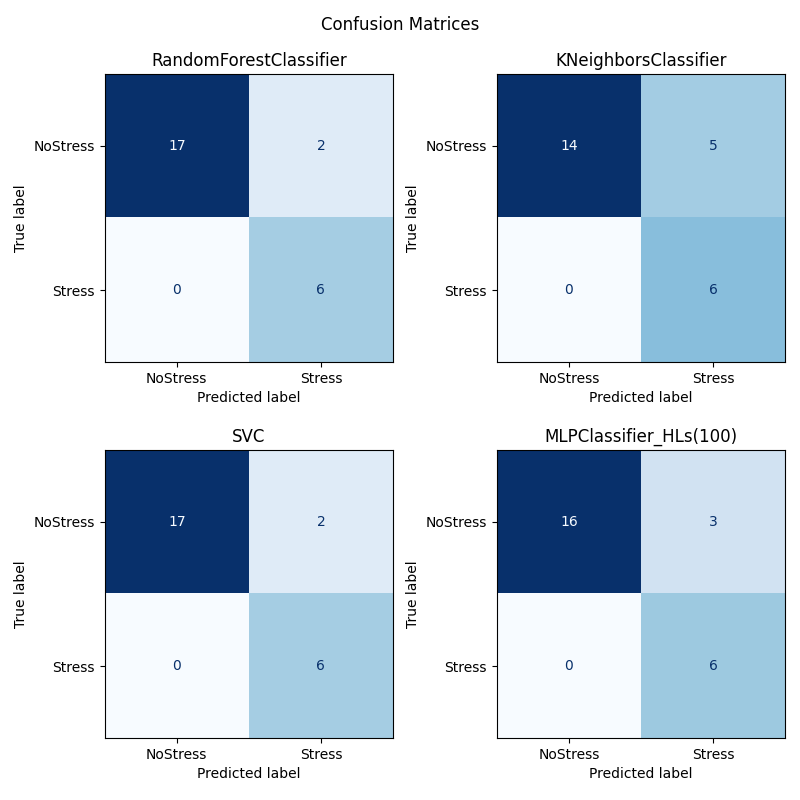

Standard Deviations 10 holdouts:


,f1-score,accuracy,time
classifier,,,
KNeighborsClassifier,0.072043,0.067599,0.568826
MLPClassifier_HLs(100),0.037618,0.034703,0.517847
RandomForestClassifier,0.046954,0.057346,0.406001
SVC,0.032310,0.030793,0.484952


In [16]:
# 10 random splits holdout
if validations['holdout']:
    res, conf, models_10h, probs_dict = make_nclassif_random_splits(
        x_in,
        y_in,
        n_splits=params["n_splits"],
        feature_selector=params["feature_selector"],
        list_classifiers=list_classif,
        random_seed=params["state_int"],
        test_size=params["test_size"],
        verbose=params["verbose"],
        useStratification=False,
    )
    output(res, conf, params)
    if params["save_models"]:
        save_models(models_10h, params)

    print(f"Standard Deviations {params['n_splits']} holdouts:")
    display(res.groupby(["classifier"]).std()[["f1-score", "accuracy", "time"]])

    if not params["data_augmentation"]:
        for model_name, probs_df in probs_dict.items():
            agg_cols = {}
            for cls_idx, cls_name in enumerate(params["classes"]):
                agg_cols[cls_idx] = cls_name
            probs_df["Subject"] = [idx.split("_")[0] for idx in probs_df.index]
            probs_df["Task"] = [idx.split("_")[1] for idx in probs_df.index]
            probs_dict[model_name] = probs_df.rename(columns=agg_cols).reset_index(drop=True)

In [14]:
if not params["data_augmentation"]:
    for model_name, probs_df in probs_dict.items():
        print(f"\n{model_name}")
        plt.figure(figsize=(12, 6))

        tasks = sorted(probs_df['Task'].unique())
        x_positions = np.arange(len(tasks))
        width = 0.35

        # Plot bars and scatter points for each class
        for i, class_name in enumerate(params["classes"]):
            means = probs_df.groupby('Task')[class_name].mean()
            bars = plt.bar(x_positions + (i-0.5)*width, [means[task] for task in tasks], width,
                        label=class_name, alpha=0.7)

            # Add scatter points
            for j, task in enumerate(tasks):
                task_data = probs_df[probs_df['Task'] == task][class_name]
                x_jitter = np.random.normal(0, 0.04, size=len(task_data))
                plt.scatter(np.repeat(x_positions[j] + (i-0.5)*width, len(task_data)) + x_jitter,
                        task_data, color='black', alpha=0.1, s=30)

        plt.xlabel('Task')
        plt.ylabel('Probability')
        plt.title(f'Class Probabilities by Task - {model_name}')
        plt.xticks(x_positions, tasks, rotation=45)
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.ylim(-0.05, 1.05)
        plt.tight_layout()
        plt.show()

        # Summary
        agg_cols = {}
        for cls_name in params["classes"]:
            agg_cols[cls_name] = ["mean", "count", "std"]
        probs_stats = probs_df.groupby("Task").agg(agg_cols)
        display(probs_stats)

In [18]:
# 5-fold cross-validation
#if validations['kfold']:
#    res, conf, models_5f, probs_dict = make_nclassif_kfold(
#        x_in,
#        y_in,
#        feature_selector=params["feature_selector"],
#        list_classifiers=list_classif,
#        random_seed=params["state_int"],
#        verbose=params["verbose"],
#        stratified=False,
#    )
#    output(res, conf, params)
#    if params["save_models"]:
#        save_models(models_5f, params)

#    print("Standard Deviations 5-folds cross-validation:")
#    display(res.groupby(["classifier"]).std()[["f1-score", "accuracy", "time"]])

#    if not params["data_augmentation"]:
#        for model_name, probs_df in probs_dict.items():
#            agg_cols = {}
#            for cls_idx, cls_name in enumerate(params["classes"]):
#                agg_cols[cls_idx] = cls_name
#            probs_df["Subject"] = [idx.split("_")[0] for idx in probs_df.index]
#            probs_df["Task"] = [idx.split("_")[1] for idx in probs_df.index]
#            probs_dict[model_name] = probs_df.rename(columns=agg_cols).reset_index(drop=True)

In [19]:
if not params["data_augmentation"]:
    for model_name, probs_df in probs_dict.items():
        print(f"\n{model_name}")
        plt.figure(figsize=(12, 6))

        tasks = sorted(probs_df['Task'].unique())
        x_positions = np.arange(len(tasks))
        width = 0.35

        # Plot bars and scatter points for each class
        for i, class_name in enumerate(params["classes"]):
            means = probs_df.groupby('Task')[class_name].mean()
            bars = plt.bar(x_positions + (i-0.5)*width, [means[task] for task in tasks], width,
                        label=class_name, alpha=0.7)

            # Add scatter points
            for j, task in enumerate(tasks):
                task_data = probs_df[probs_df['Task'] == task][class_name]
                x_jitter = np.random.normal(0, 0.04, size=len(task_data))
                plt.scatter(np.repeat(x_positions[j] + (i-0.5)*width, len(task_data)) + x_jitter,
                        task_data, color='black', alpha=0.1, s=30)

        plt.xlabel('Task')
        plt.ylabel('Probability')
        plt.title(f'Class Probabilities by Task - {model_name}')
        plt.xticks(x_positions, tasks, rotation=45)
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.ylim(-0.05, 1.05)
        plt.tight_layout()
        plt.show()

        # Summary
        agg_cols = {}
        for cls_name in params["classes"]:
            agg_cols[cls_name] = ["mean", "count", "std"]
        probs_stats = probs_df.groupby("Task").agg(agg_cols)
        display(probs_stats)

### Binary test set inference (Calculator or Video tasks)



============ binary ============


Trained on VIDEO


,counts,percentage
labels,,
NoStress,63,50.806452
Stress,61,49.193548



Tested on CALC


,counts,percentage
labels,,
NoStress,36,57.142857
Stress,27,42.857143


,bal-accuracy,weighted-f1,macro-avg-prec,macro-avg-rec,macro-avg-f1,stress-prec,stress-rec,stress-f1
classifier,,,,,,,,
RandomForestClassifier,0.444444,0.431306,0.405594,0.444444,0.397129,0.272727,0.111111,0.157895
KNeighborsClassifier,0.421296,0.434137,0.415188,0.421296,0.415584,0.318182,0.259259,0.285714
SVC,0.351852,0.340365,0.278462,0.351852,0.304070,0.076923,0.037037,0.050000
MLPClassifier_HLs(100),0.500000,0.508945,0.500000,0.500000,0.499872,0.428571,0.444444,0.436364


Saving results to ../../experiment-data/results/InterTasks/20251021-163341_binary_video_RFEf.21.csv
Saving confusion matrix to ../../experiment-data/results/InterTasks/20251021-163341_binary_video_RFEf.21.CM.png


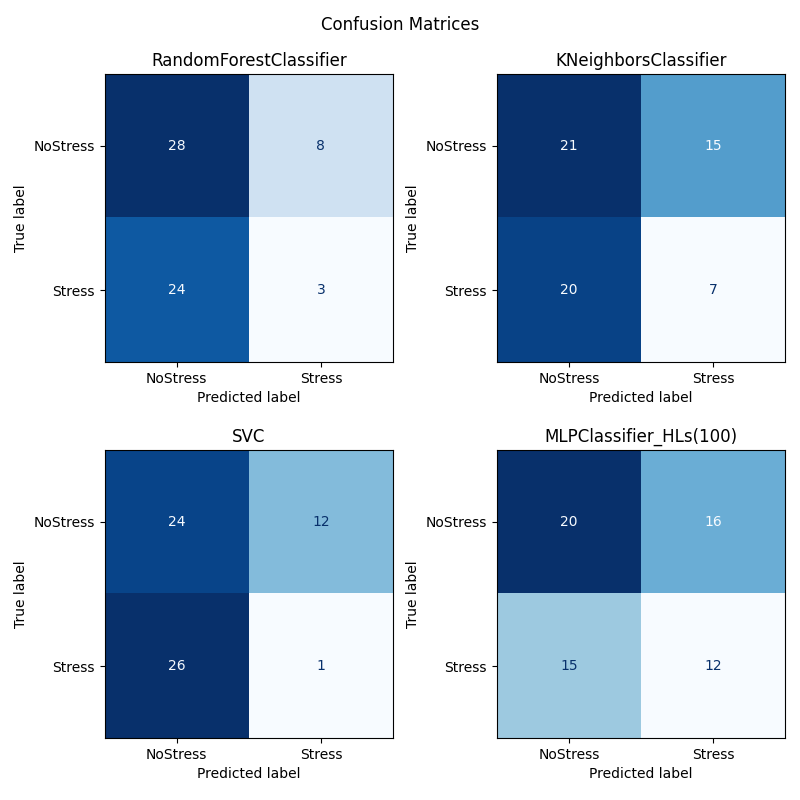

In [21]:
print(f"\n\n============ {params['classification']} ============\n\n")
print(f"Trained on {params['training_tasks'].upper()}")
show_label_stats(params["classes"], y_in)

log_type = f"{params['classification']}_{params['training_tasks']}"
df_res = pd.DataFrame(
    {
        "classifier": [],
        "bal-accuracy": [],
        "weighted-f1": [],
        "macro-avg-prec": [],
        "macro-avg-rec": [],
        "macro-avg-f1": [],
        "stress-prec": [],
        "stress-rec": [],
        "stress-f1": [],
    },
)
conf_matrices: dict[str, np.ndarray] = {}

for model_name, model in models_10h.items():
    y_pred = model.predict(testset_x)
    cm = confusion_matrix(testset_bin_y, y_pred)
    report = classification_report(testset_bin_y, y_pred, target_names=params["classes"], output_dict=True)
    conf_matrices[model_name] = cm

    s_report = report["Stress"]
    m_report = report["macro avg"]
    new_row = {
        "classifier": model_name,
        "bal-accuracy": balanced_accuracy_score(testset_bin_y, y_pred),
        "weighted-f1": f1_score(testset_bin_y, y_pred, average="weighted"),
        "macro-avg-prec": m_report["precision"],
        "macro-avg-rec": m_report["recall"],
        "macro-avg-f1": m_report["f1-score"],
        "stress-prec": s_report["precision"],
        "stress-rec": s_report["recall"],
        "stress-f1": s_report["f1-score"],
    }
    df_res.loc[len(df_res)] = new_row

print(f"\nTested on {params['testing_tasks'].upper()}")
show_label_stats(params["classes"], testset_bin_y)

df_res.set_index("classifier", inplace=True)
show_results(log_type, df_res, params, save=params["save_results"])
if params["show_confusion_matrices"]:
    show_confusion_matrices(log_type, conf_matrices, params, save=params["save_confusion_matrices"])

### Ternary classification

In [26]:
params['classification'] = 'ternary'
params['classes'] = TER_LABELS
show_label_stats(params['classes'], trainset_ter_y)

if params["data_augmentation"]:
    ada = ADASYN(random_state=params["state_int"], sampling_strategy={0:52, 1:52, 2:52}) # sampling_strategy={0:49, 1:49, 2:49}) for calc
    x_in, y_in = ada.fit_resample(trainset_x, trainset_ter_y)
    print("Resampled dataset")
    show_label_stats(params['classes'], y_in)
else:
    x_in = trainset_x.copy()
    y_in = trainset_ter_y.copy()

,counts,percentage
labels,,
Relaxed,43,68.253968
Stress,13,20.634921
RealStress,7,11.111111


Resampled dataset


,counts,percentage
labels,,
Relaxed,52,34.666667
Stress,52,34.666667
RealStress,46,30.666667


Split  1/10
Split  2/10
Split  3/10
Split  4/10
Split  5/10
Split  6/10
Split  7/10
Split  8/10
Split  9/10
Split 10/10
Saving results to ../../experiment-data/results/InterTasks/20251021-163939_ternary_video_RFEf.21.csv, ../../experiment-data/results/InterTasks/20251021-163939_ternary_video_RFEf.21.avg.csv


,f1-score,accuracy,time
classifier,,,
KNeighborsClassifier,0.843340,0.842828,5.284623
MLPClassifier_HLs(100),0.875452,0.871212,5.534695
RandomForestClassifier,0.860067,0.856768,5.671389
SVC,0.900105,0.897071,5.514753


Saving confusion matrix to ../../experiment-data/results/InterTasks/20251021-163939_ternary_video_RFEf.21.CM.png


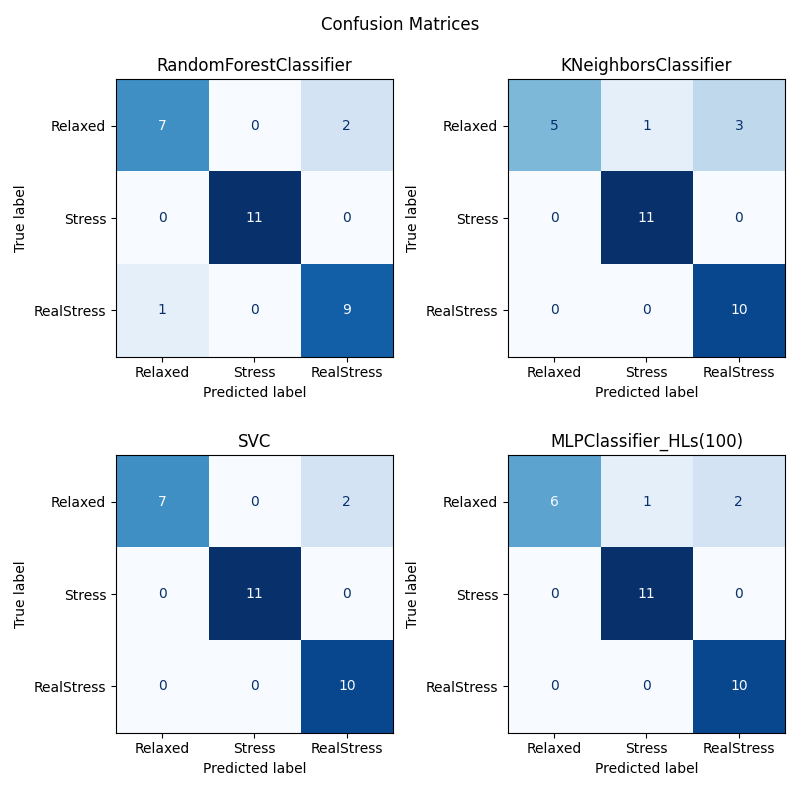

Standard Deviations 10 holdouts:


,f1-score,accuracy,time
classifier,,,
KNeighborsClassifier,0.064445,0.058575,0.617117
MLPClassifier_HLs(100),0.072867,0.073075,0.574671
RandomForestClassifier,0.048146,0.045275,0.532591
SVC,0.055295,0.053239,0.578071


In [27]:
# 10 random splits holdout
if validations["holdout"]:
    res, conf, models_10h, probs_dict = make_nclassif_random_splits(
        x_in,
        y_in,
        n_splits=params["n_splits"],
        feature_selector=params["feature_selector"],
        list_classifiers=list_classif,
        random_seed=params["state_int"],
        test_size=params["test_size"],
        verbose=params["verbose"],
        useStratification=True,
    )
    output(res, conf, params)
    if params["save_models"]:
        save_models(models_10h, params)

    print(f"Standard Deviations {params['n_splits']} holdouts:")
    display(res.groupby(["classifier"]).std()[["f1-score", "accuracy", "time"]])


In [ ]:
# 5-fold cross-validation
if validations["kfold"]:
    res, conf, models_5f, probs_dict = make_nclassif_kfold(
        x_in,
        y_in,
        feature_selector=params["feature_selector"],
        list_classifiers=list_classif,
        random_seed=params["state_int"],
        verbose=params["verbose"],
        stratified=True,
    )
    output(res, conf, params)
    if params["save_models"]:
        save_models(models_5f, params)

    print("Standard Deviations 5-folds cross-validation:")
    display(res.groupby(["classifier"]).std()[["f1-score", "accuracy", "time"]])

Fold 1/5
Fold 2/5
Fold 3/5


In [ ]:
print(f"\n\n============ {params['classification']} ============\n\n")
print(f"Trained on {params['training_tasks'].upper()}")
show_label_stats(params["classes"], y_in)

log_type = f"{params['classification']}_{params['training_tasks']}"
df_res = pd.DataFrame(
    {
        "classifier": [],
        "bal-accuracy": [],
        "weighted-f1": [],
        "macro-avg-prec": [],
        "macro-avg-rec": [],
        "macro-avg-f1": [],
        "stress-prec": [],
        "stress-rec": [],
        "stress-f1": [],
    },
)
conf_matrices: dict[str, np.ndarray] = {}

for model_name, model in models_10h.items():
    y_pred = model.predict(testset_x)
    cm = confusion_matrix(testset_ter_y, y_pred)
    report = classification_report(testset_ter_y, y_pred, target_names=params["classes"], output_dict=True)
    conf_matrices[model_name] = cm

    s_report = report["Stress"]
    m_report = report["macro avg"]
    new_row = {
        "classifier": model_name,
        "bal-accuracy": balanced_accuracy_score(testset_ter_y, y_pred),
        "weighted-f1": f1_score(testset_ter_y, y_pred, average="weighted"),
        "macro-avg-prec": m_report["precision"],
        "macro-avg-rec": m_report["recall"],
        "macro-avg-f1": m_report["f1-score"],
        "stress-prec": s_report["precision"],
        "stress-rec": s_report["recall"],
        "stress-f1": s_report["f1-score"],
    }
    df_res.loc[len(df_res)] = new_row

print(f"\nTested on {params['testing_tasks'].upper()}")
show_label_stats(params["classes"], testset_ter_y)

df_res.set_index("classifier", inplace=True)
show_results(log_type, df_res, params, save=params["save_results"])
if params["show_confusion_matrices"]:
    show_confusion_matrices(log_type, conf_matrices, params, save=params["save_confusion_matrices"])


### Quaternary Classification

In [ ]:
params["classification"] = "quaternary"
params["classes"] = QAD_LABELS
show_label_stats(params["classes"], trainset_qad_y)

if params["data_augmentation"]:
    ada = ADASYN(random_state=params["state_int"], sampling_strategy="not minority")
    x_in, y_in = ada.fit_resample(trainset_x, trainset_qad_y)
    print("Resampled dataset")
    show_label_stats(params["classes"], y_in)
else:
    x_in = trainset_x.copy()
    y_in = trainset_qad_y.copy()

In [ ]:
# 10 random splits holdout
if validations["holdout"]:
    res, conf, models_10h, probs_dict = make_nclassif_random_splits(
        x_in,
        y_in,
        n_splits=params["n_splits"],
        feature_selector=params["feature_selector"],
        list_classifiers=list_classif,
        random_seed=params["state_int"],
        test_size=params["test_size"],
        verbose=params["verbose"],
        useStratification=True,
    )
    output(res, conf, params)
    if params["save_models"]:
        save_models(models_10h, params)

    print(f"Standard Deviations {params['n_splits']} holdouts:")
    display(res.groupby(["classifier"]).std()[["f1-score", "accuracy", "time"]])

In [ ]:
# 5-fold cross-validation
if validations["kfold"]:
    res, conf, models_5f, probs_dict = make_nclassif_kfold(
        x_in,
        y_in,
        feature_selector=params["feature_selector"],
        list_classifiers=list_classif,
        random_seed=params["state_int"],
        verbose=params["verbose"],
        stratified=True,
    )
    output(res, conf, params)
    if params["save_models"]:
        save_models(models_5f, params)

    print("Standard Deviations 5-folds cross-validation:")
    display(res.groupby(["classifier"]).std()[["f1-score", "accuracy", "time"]])

In [ ]:
print(f"\n\n============ {params['classification']} ============\n\n")
print(f"Trained on {params['training_tasks'].upper()}")
show_label_stats(params["classes"], y_in)

log_type = f"{params['classification']}_{params['training_tasks']}"
df_res = pd.DataFrame(
    {
        "classifier": [],
        "bal-accuracy": [],
        "weighted-f1": [],
        "macro-avg-prec": [],
        "macro-avg-rec": [],
        "macro-avg-f1": [],
        "stress-prec": [],
        "stress-rec": [],
        "stress-f1": [],
    },
)
conf_matrices: dict[str, np.ndarray] = {}

for model_name, model in models_5f.items():
    y_pred = model.predict(testset_x)
    cm = confusion_matrix(testset_qad_y, y_pred)
    report = classification_report(testset_qad_y, y_pred, target_names=params["classes"], output_dict=True)
    conf_matrices[model_name] = cm

    s_report = report["Stress"]
    m_report = report["macro avg"]
    new_row = {
        "classifier": model_name,
        "bal-accuracy": balanced_accuracy_score(testset_qad_y, y_pred),
        "weighted-f1": f1_score(testset_qad_y, y_pred, average="weighted"),
        "macro-avg-prec": m_report["precision"],
        "macro-avg-rec": m_report["recall"],
        "macro-avg-f1": m_report["f1-score"],
        "stress-prec": s_report["precision"],
        "stress-rec": s_report["recall"],
        "stress-f1": s_report["f1-score"],
    }
    df_res.loc[len(df_res)] = new_row

print(f"\nTested on {params['testing_tasks'].upper()}")
show_label_stats(params["classes"], testset_qad_y)

df_res.set_index("classifier", inplace=True)
show_results(log_type, df_res, params, save=params["save_results"])
if params["show_confusion_matrices"]:
    show_confusion_matrices(log_type, conf_matrices, params, save=params["save_confusion_matrices"])
